In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def step_function(x):
    return 1 if x >= 0 else 0

def perceptron_train(X, y, lr=1, epochs=10, gate_name="Gate"):
    """
    X : input features (without bias)
    y : target labels
    lr: learning rate
    Returns final weights and a history of weights after every update
    """
    n_samples, n_features = X.shape
    # weights[0] is bias, weights[1:] are feature weights
    weights = np.zeros(n_features + 1)
    history = [weights.copy()]

    print(f"\n===== Training {gate_name} Gate =====")
    print(f"Initial weights (bias, w1, w2...): {weights}")

    update_count = 0
    for epoch in range(epochs):
        total_errors = 0
        for xi, target in zip(X, y):
            xi_bias = np.insert(xi, 0, 1)  # add bias input = 1
            net_input = np.dot(weights, xi_bias)
            prediction = step_function(net_input)
            error = target - prediction

            if error != 0:
                update = lr * error
                weights = weights + update * xi_bias
                history.append(weights.copy())
                update_count += 1
                total_errors += 1
                print(f"Epoch {epoch+1} | Input: {xi} | Target: {target} | "
                      f"Pred: {prediction} | Update #{update_count} -> Weights: {weights}")

        if total_errors == 0:
            print(f"Converged after {epoch+1} epoch(s), {update_count} weight updates.")
            break

    return weights, history

In [15]:
def plot_decision_boundary_2input(X, y, weights, title):
    plt.figure(figsize=(5, 5))

    b, w1, w2 = weights

    # Shade the decision regions across the whole plot so separation is
    # visible even when the boundary line itself is steep
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 300), np.linspace(-0.5, 1.5, 300))
    grid = b + w1 * xx + w2 * yy
    zz = (grid >= 0).astype(int)
    plt.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5],
                 colors=['#ffe0e0', '#e0e0ff'], alpha=0.6)

    for xi, target in zip(X, y):
        color = 'blue' if target == 1 else 'red'
        marker = 'o' if target == 1 else 'x'
        plt.scatter(xi[0], xi[1], c=color, marker=marker, s=150,
                    edgecolors='k', zorder=5)

    # Extend the line far beyond the visible window so it still shows up
    # correctly wherever it crosses the frame
    if w2 != 0:
        x_vals = np.array([-10, 10])
        y_vals = -(b + w1 * x_vals) / w2
        plt.plot(x_vals, y_vals, 'g-', linewidth=2, zorder=4)
    elif w1 != 0:
        plt.axvline(x=-b / w1, color='g', linewidth=2, zorder=4)

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_all_updates_2input(X, y, history, gate_name):
    for i, w in enumerate(history):
        title = f"{gate_name} Gate - After Update {i} | Weights: {np.round(w,2)}"
        plot_decision_boundary_2input(X, y, w, title)

In [16]:
def plot_decision_boundary_1input(X, y, weights, title):
    plt.figure(figsize=(5, 2))

    for xi, target in zip(X, y):
        color = 'blue' if target == 1 else 'red'
        plt.scatter(xi[0], 0, c=color, s=150)

    b, w1 = weights
    if w1 != 0:
        boundary = -b / w1
        plt.axvline(x=boundary, color='g', linewidth=2)

    plt.xlim(-1, 2)
    plt.yticks([])
    plt.xlabel("x1")
    plt.title(title)
    plt.grid(True)
    plt.show()

def plot_all_updates_1input(X, y, history, gate_name):
    for i, w in enumerate(history):
        title = f"{gate_name} Gate - After Update {i} | Weights: {np.round(w,2)}"
        plot_decision_boundary_1input(X, y, w, title)


===== Training AND Gate =====
Initial weights (bias, w1, w2...): [0. 0. 0.]
Epoch 1 | Input: [0 0] | Target: 0 | Pred: 1 | Update #1 -> Weights: [-1.  0.  0.]
Epoch 1 | Input: [1 1] | Target: 1 | Pred: 0 | Update #2 -> Weights: [0. 1. 1.]
Epoch 2 | Input: [0 0] | Target: 0 | Pred: 1 | Update #3 -> Weights: [-1.  1.  1.]
Epoch 2 | Input: [0 1] | Target: 0 | Pred: 1 | Update #4 -> Weights: [-2.  1.  0.]
Epoch 2 | Input: [1 1] | Target: 1 | Pred: 0 | Update #5 -> Weights: [-1.  2.  1.]
Epoch 3 | Input: [0 1] | Target: 0 | Pred: 1 | Update #6 -> Weights: [-2.  2.  0.]
Epoch 3 | Input: [1 0] | Target: 0 | Pred: 1 | Update #7 -> Weights: [-3.  1.  0.]
Epoch 3 | Input: [1 1] | Target: 1 | Pred: 0 | Update #8 -> Weights: [-2.  2.  1.]
Epoch 4 | Input: [1 0] | Target: 0 | Pred: 1 | Update #9 -> Weights: [-3.  1.  1.]
Epoch 4 | Input: [1 1] | Target: 1 | Pred: 0 | Update #10 -> Weights: [-2.  2.  2.]
Epoch 5 | Input: [0 1] | Target: 0 | Pred: 1 | Update #11 -> Weights: [-3.  2.  1.]
Converged a

/tmp/ipykernel_1703/744959619.py:17: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(xi[0], xi[1], c=color, marker=marker, s=150,


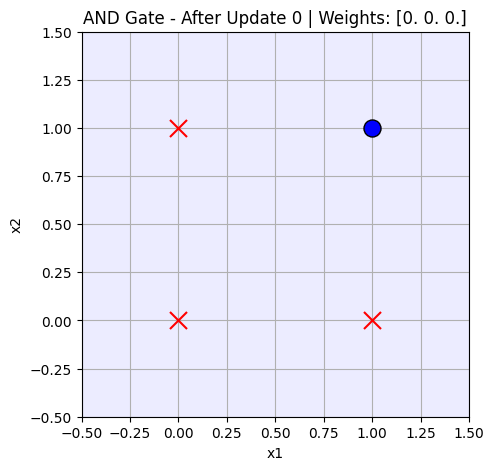

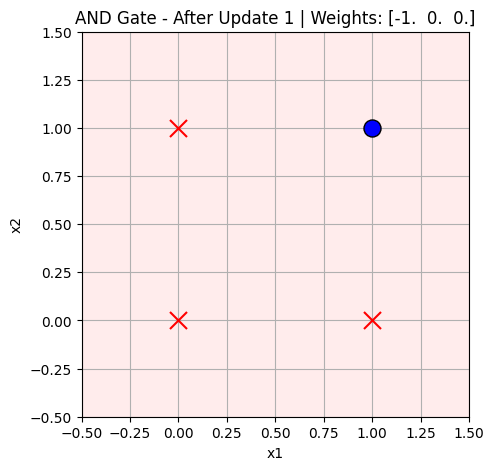

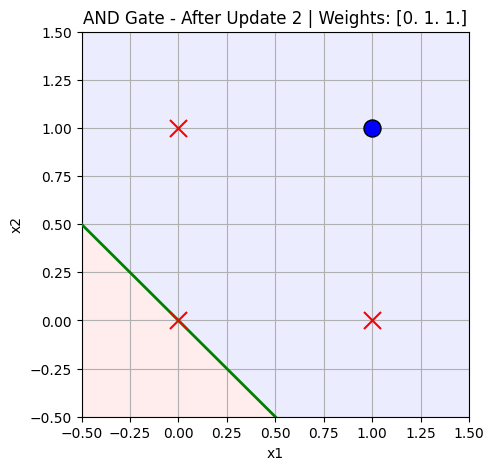

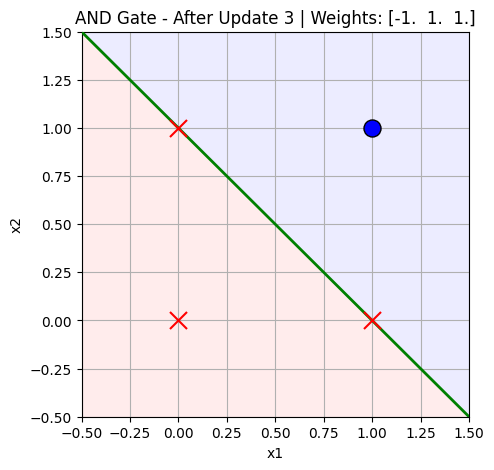

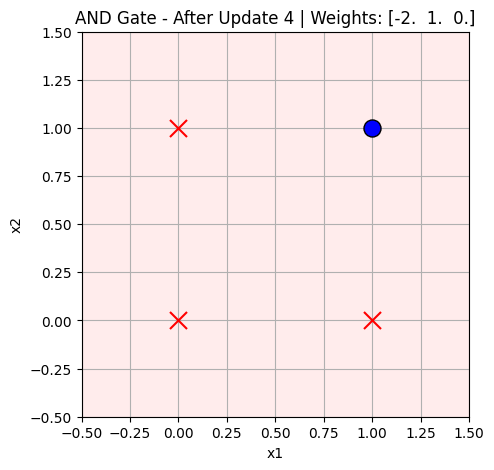

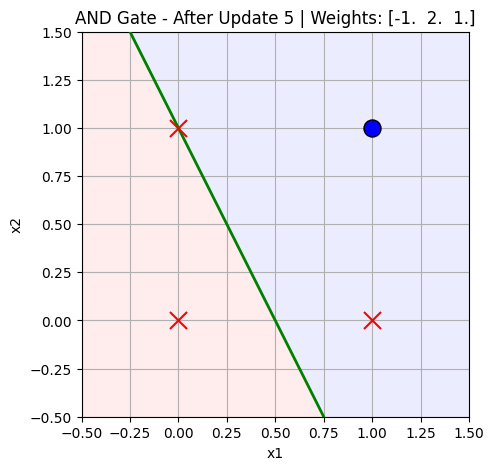

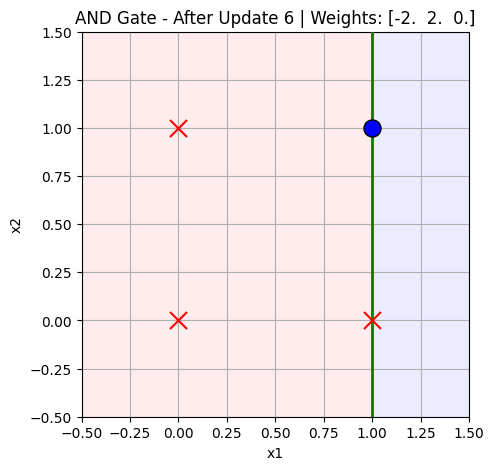

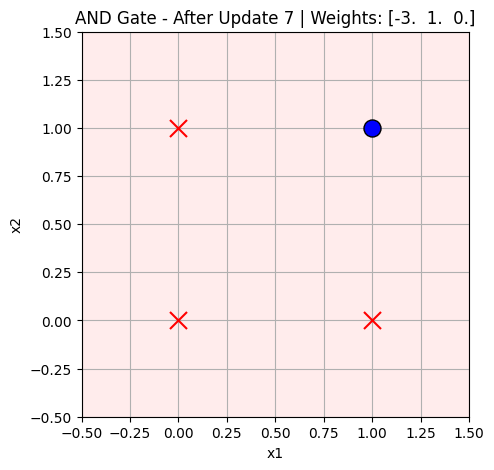

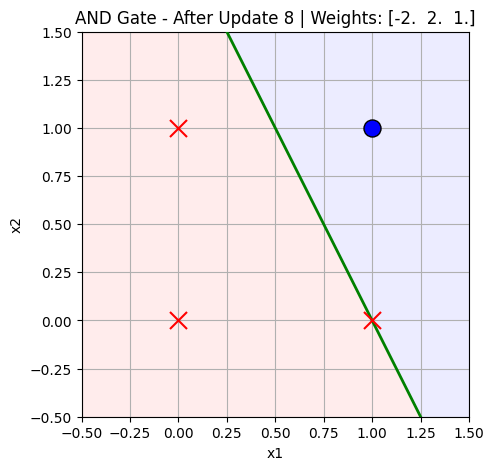

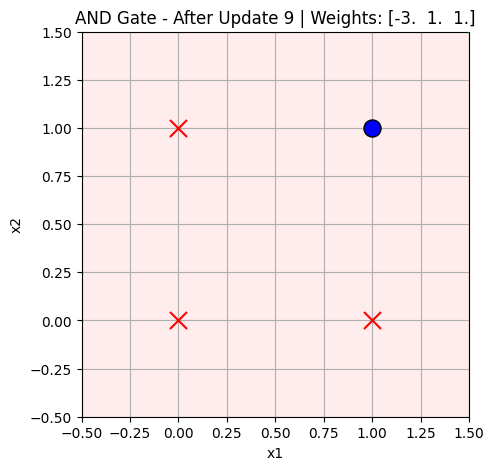

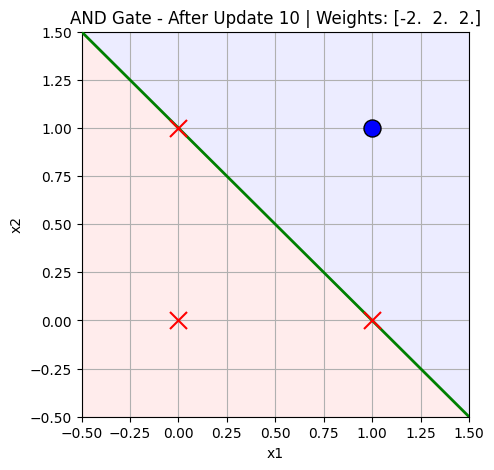

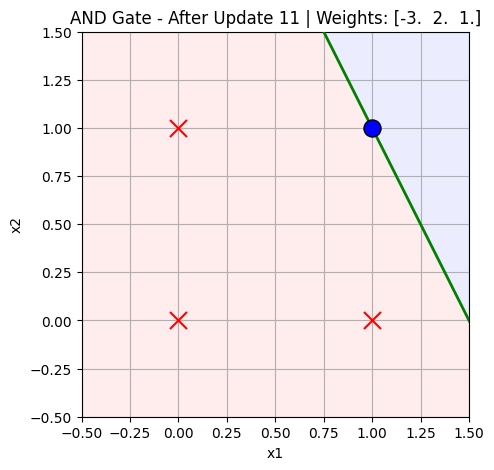

In [17]:
X_and = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])

w_and, hist_and = perceptron_train(X_and, y_and, lr=1, epochs=10, gate_name="AND")
plot_all_updates_2input(X_and, y_and, hist_and, "AND")


===== Training OR Gate =====
Initial weights (bias, w1, w2...): [0. 0. 0.]
Epoch 1 | Input: [0 0] | Target: 0 | Pred: 1 | Update #1 -> Weights: [-1.  0.  0.]
Epoch 1 | Input: [0 1] | Target: 1 | Pred: 0 | Update #2 -> Weights: [0. 0. 1.]
Epoch 2 | Input: [0 0] | Target: 0 | Pred: 1 | Update #3 -> Weights: [-1.  0.  1.]
Epoch 2 | Input: [1 0] | Target: 1 | Pred: 0 | Update #4 -> Weights: [0. 1. 1.]
Epoch 3 | Input: [0 0] | Target: 0 | Pred: 1 | Update #5 -> Weights: [-1.  1.  1.]
Converged after 4 epoch(s), 5 weight updates.


/tmp/ipykernel_1703/744959619.py:17: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(xi[0], xi[1], c=color, marker=marker, s=150,


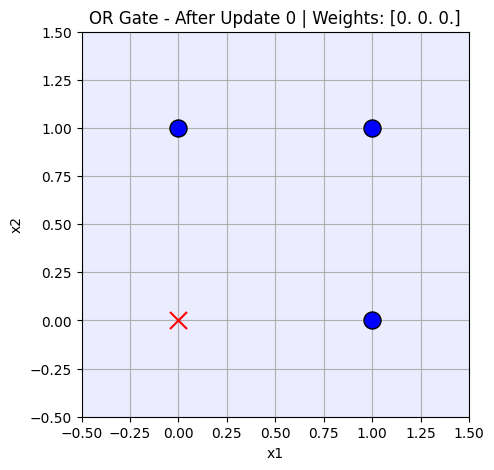

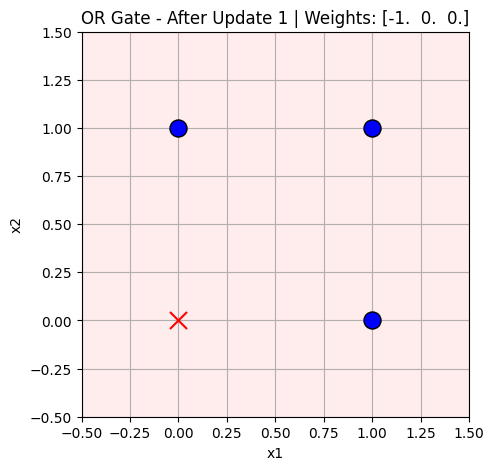

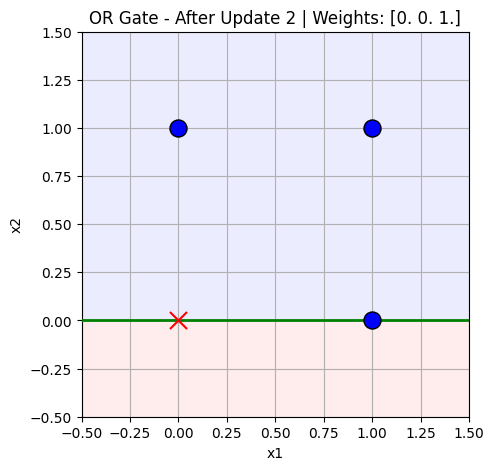

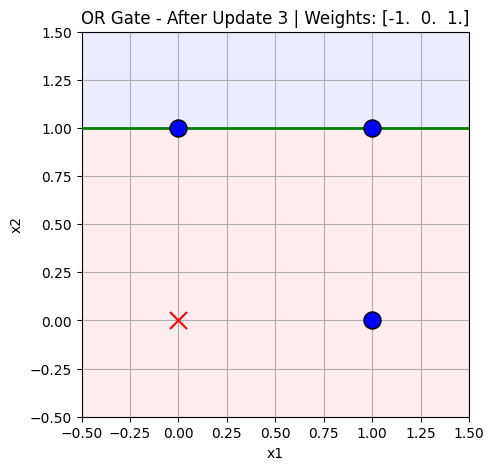

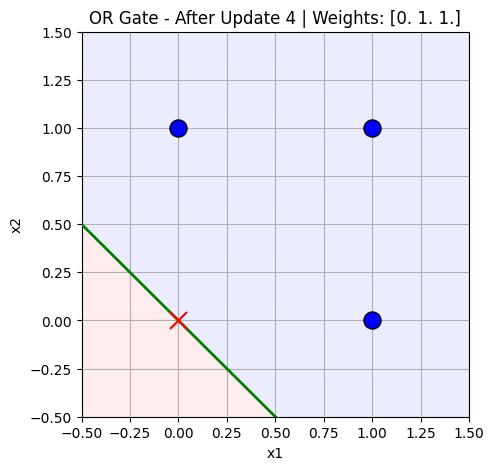

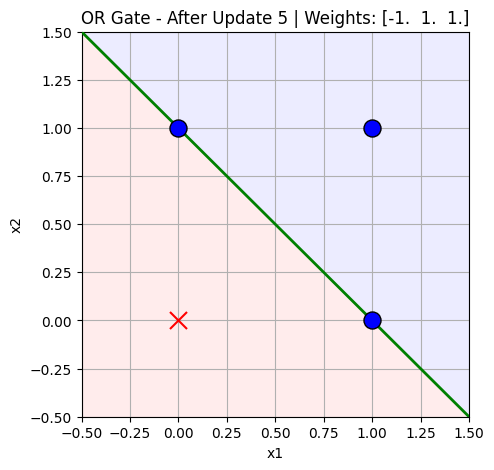

In [18]:
X_or = np.array([[0,0],[0,1],[1,0],[1,1]])
y_or = np.array([0,1,1,1])

w_or, hist_or = perceptron_train(X_or, y_or, lr=1, epochs=10, gate_name="OR")
plot_all_updates_2input(X_or, y_or, hist_or, "OR")


===== Training NOT Gate =====
Initial weights (bias, w1, w2...): [0. 0.]
Epoch 1 | Input: [1] | Target: 0 | Pred: 1 | Update #1 -> Weights: [-1. -1.]
Epoch 2 | Input: [0] | Target: 1 | Pred: 0 | Update #2 -> Weights: [ 0. -1.]
Converged after 3 epoch(s), 2 weight updates.


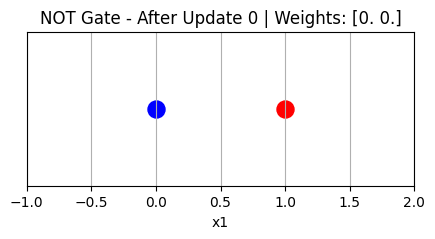

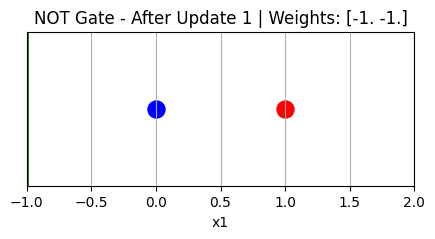

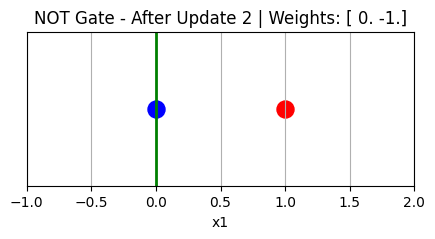

In [19]:
X_not = np.array([[0],[1]])
y_not = np.array([1,0])

w_not, hist_not = perceptron_train(X_not, y_not, lr=1, epochs=10, gate_name="NOT")
plot_all_updates_1input(X_not, y_not, hist_not, "NOT")